# Shea Homes Customer Review Analysis
### Notebook: `03_sentiment_analysis`

> Run `01_setup_and_summary_stats.ipynb` first, or execute the setup cell below.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy import stats
import re
import warnings
warnings.filterwarnings("ignore")

# nlp tools
import nltk
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud
import spacy

#ml
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

# visual style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
SHEA_BLUE = "#1a5276"
SHEA_GOLD = "#d4a843"
SHEA_PALETTE = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60", "#1a5276"]

# keep apostrophes so contractions like "don't" stay as one token
TOKEN_PATTERN = r"(?u)\b\w[\w']+\b"

In [3]:
# load the dataset
df = pd.read_csv("../shea_homes_reviews.csv", encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# derived columns
df["word_count"] = df["review_text"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["review_text"].apply(lambda x: len(str(x)))
df["state"] = df["location"].str.extract(r",\s*([A-Z]{2})$")
df["year"] = df["date"].dt.year
df["year_month"] = df["date"].dt.to_period("M")
df["quarter"] = df["date"].dt.to_period("Q")

print(f"{len(df):,} reviews")
print(f"Date range: {df['date'].min().strftime('%B %Y')} to {df['date'].max().strftime('%B %Y')}")
df.head(3)

2,052 reviews
Date range: September 2020 to April 2026


,title,reviewer_name,verified_homebuyer,date,location,review_text,total_score,quality,trustworthiness,value,responsiveness,word_count,char_count,state,year,year_month,quarter
0,Good overall,Constance G.,Yes,2026-04-01,"OCALA, FL",A little overwhelming for me as a single elder...,5,5,5,5,5,86,434,FL,2026,2026-04,2026Q2
1,"Excellent, knowledgeable and responsive",Emily V.,Yes,2026-03-31,"Littleton, CO",Our experience exceeded our expectations. The ...,5,5,5,5,5,32,218,CO,2026,2026-03,2026Q1
2,Overall great experience!,Lynn S.,Yes,2026-03-26,"Kuna, ID",This is our second Shea home! Our whole proces...,5,5,5,5,5,83,516,ID,2026,2026-03,2026Q1


---
# Part 3: Preliminary Sentiment Analysis

Sentiment analysis is a natural language processing technique that allows an algorithm to evaluate written feedback and estimate the emotional tone of the text. Instead of manually reading thousands of reviews, algorithms analyze the words used in each comment to determine whether the overall message is positive, negative, or neutral. Words associated with positive experiences (such as “great” or “helpful”) increase the sentiment score, while words associated with problems or frustration decrease it.

Each review is converted into a numerical sentiment score ranging from −1 to +1, where −1 represents very negative language and +1 represents very positive language. To increase reliability, this analysis uses two widely used sentiment models. VADER (Valence Aware Dictionary and sEntiment Reasoner) is designed specifically for social media and review text and accounts for emphasis such as capitalization, punctuation, and emotional wording. TextBlob is a general-purpose language model that evaluates sentiment based on the balance of positive and negative terms within the text. Using two independent methods allows the analysis to compare results and confirm that the patterns observed in customer sentiment are consistent.


## 3.1 Running Sentiment Analysis

In [6]:
# VADER 
# VADER gives each review a "compound" score from -1 (most negative) to +1 (most positive)
sia = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    scores = sia.polarity_scores(str(text))
    return scores["compound"], scores["pos"], scores["neg"], scores["neu"]

vader_results = df["review_text"].apply(get_vader_scores)
df["vader_compound"] = vader_results.apply(lambda x: x[0])
df["vader_pos"] = vader_results.apply(lambda x: x[1])
df["vader_neg"] = vader_results.apply(lambda x: x[2])
df["vader_neu"] = vader_results.apply(lambda x: x[3])

# classify: compound >= 0.05 = positive, <= -0.05 = negative, else neutral
df["vader_label"] = df["vader_compound"].apply(
    lambda x: "Positive" if x >= 0.05 else ("Negative" if x <= -0.05 else "Neutral")
)

# textblob
# textblob gives polarity (-1 to +1) and subjectivity (0 = fact, 1 = opinion)
df["textblob_polarity"] = df["review_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df["textblob_subjectivity"] = df["review_text"].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

df["textblob_label"] = df["textblob_polarity"].apply(
    lambda x: "Positive" if x > 0.05 else ("Negative" if x < -0.05 else "Neutral")
)

print("=== VADER Results ===")
print(df["vader_label"].value_counts().to_string())
print("\n=== TextBlob Results ===")
print(df["textblob_label"].value_counts().to_string())

=== VADER Results ===
vader_label
Positive    1611
Negative     328
Neutral      113

=== TextBlob Results ===
textblob_label
Positive    1650
Neutral      237
Negative     165


## 3.2 Overall Sentiment Breakdown
These charts summarize how each sentiment model classified the reviews. The pie charts show the percentage of reviews labeled positive, neutral, or negative by each tool. The chart on the right compares the average sentiment score with the star rating to verify that the models behave as expected. If the models are working correctly, reviews with higher star ratings should also show more positive sentiment

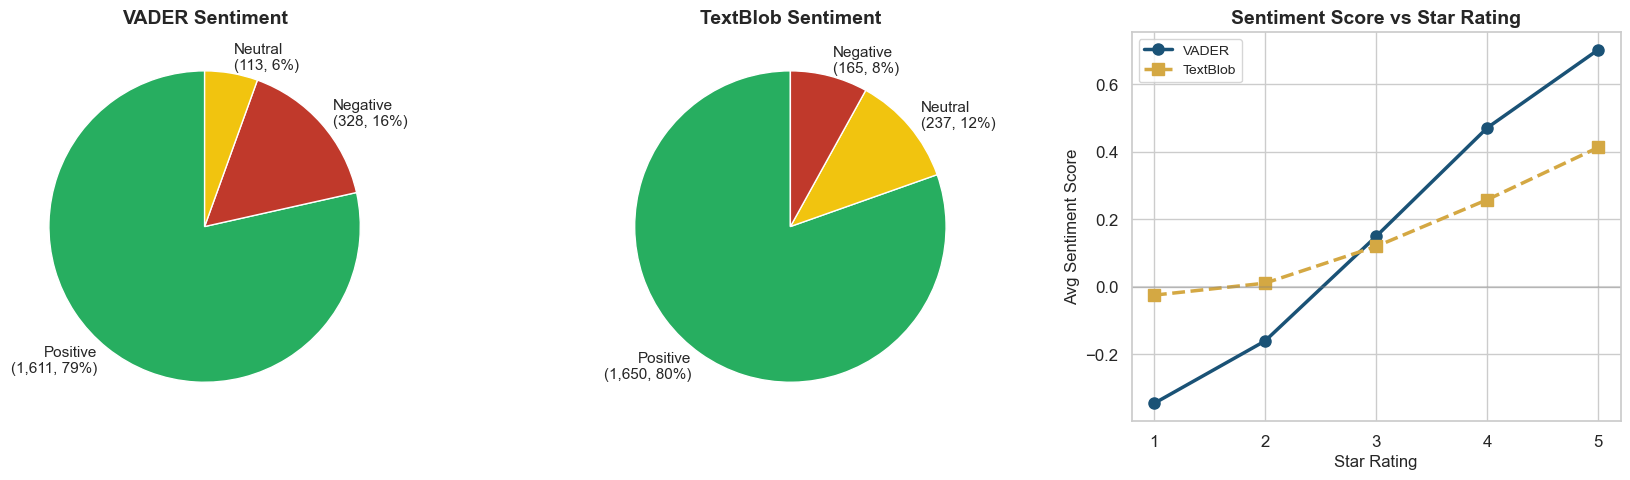

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sent_colors = {"Positive": "#27ae60", "Neutral": "#f1c40f", "Negative": "#c0392b"}

# VADER pie
vader_counts = df["vader_label"].value_counts()
axes[0].pie(vader_counts, labels=[f"{l}\n({v:,}, {v/len(df):.0%})" for l, v in vader_counts.items()],
            colors=[sent_colors[l] for l in vader_counts.index],
            startangle=90, textprops={"fontsize": 11})
axes[0].set_title("VADER Sentiment", fontsize=14, fontweight="bold")

# TextBlob pie
tb_counts = df["textblob_label"].value_counts()
axes[1].pie(tb_counts, labels=[f"{l}\n({v:,}, {v/len(df):.0%})" for l, v in tb_counts.items()],
            colors=[sent_colors[l] for l in tb_counts.index],
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("TextBlob Sentiment", fontsize=14, fontweight="bold")

# Sentiment score by star rating 
star_sentiment = df.groupby("total_score")[["vader_compound", "textblob_polarity"]].mean()
x = star_sentiment.index
axes[2].plot(x, star_sentiment["vader_compound"], "o-", color=SHEA_BLUE, linewidth=2.5,
             markersize=8, label="VADER")
axes[2].plot(x, star_sentiment["textblob_polarity"], "s--", color=SHEA_GOLD, linewidth=2.5,
             markersize=8, label="TextBlob")
axes[2].axhline(y=0, color="gray", linestyle="-", alpha=0.3)
axes[2].set_xlabel("Star Rating", fontsize=12)
axes[2].set_ylabel("Avg Sentiment Score", fontsize=12)
axes[2].set_title("Sentiment Score vs Star Rating", fontsize=14, fontweight="bold")
axes[2].set_xticks([1, 2, 3, 4, 5])
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

Both models produce similar results, showing that the majority of reviews contain positive language. VADER classifies about 78% of reviews as positive, while TextBlob identifies roughly 80% as positive. VADER detects more negative reviews than TextBlob, reflecting its stronger sensitivity to negative wording in review-style text.

The sentiment vs. star rating chart provides a validation check. Sentiment scores increase steadily from 1-star to 5-star reviews, confirming that both models are interpreting the language in a way that aligns with the rating customers assigned.


## 3.3 Sentiment Trends Over Time

This section examines how customer sentiment has changed over time. Reviews are grouped by quarter to identify broader trends. The top chart shows the average sentiment score per quarter, while the bottom chart shows the percentage of reviews classified as positive and negative during each period.

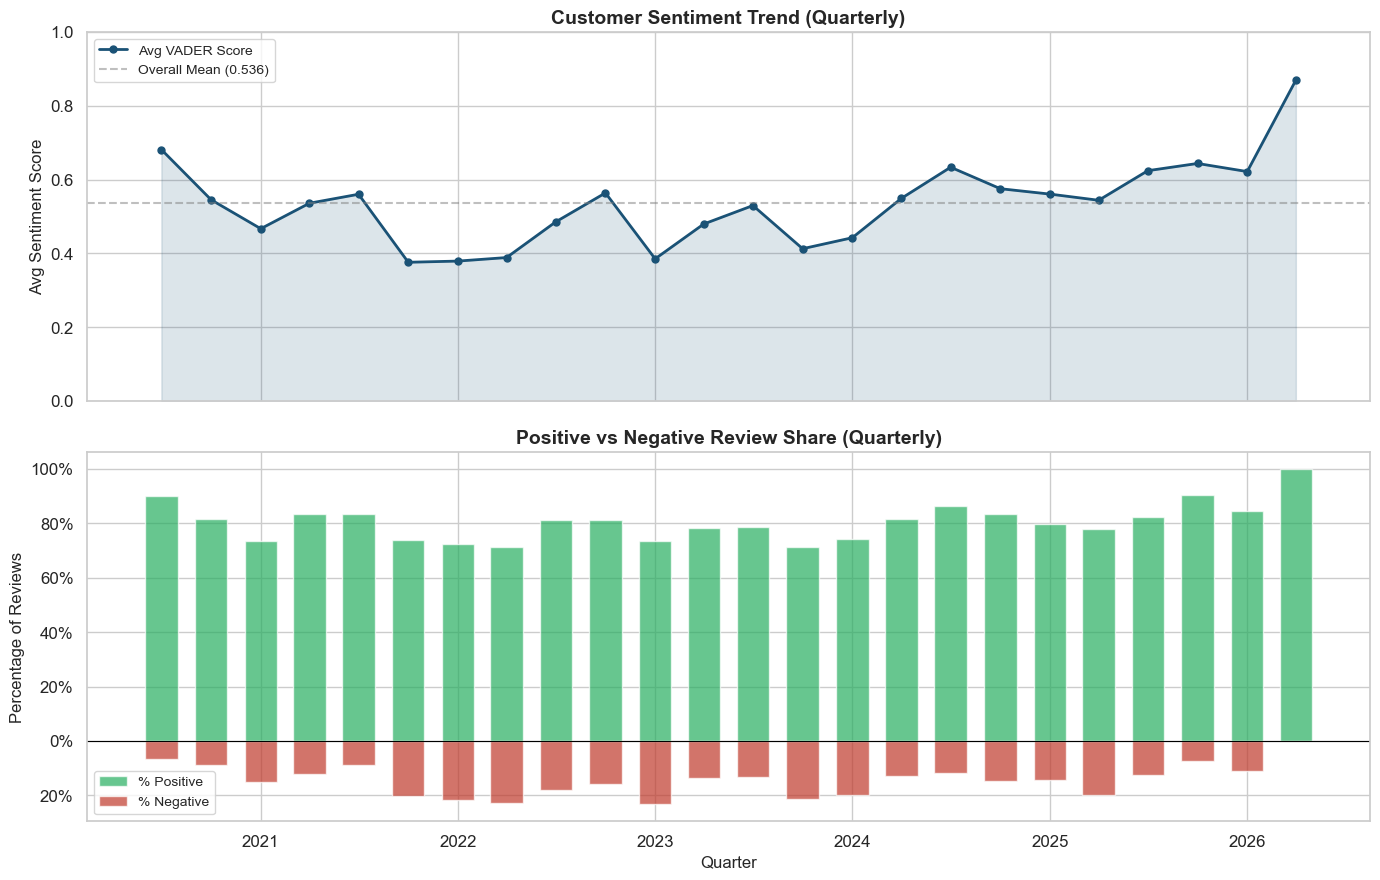

In [11]:
# quarterly sentiment trend
df["quarter"] = df["date"].dt.to_period("Q")
quarterly = df.groupby("quarter").agg(
    avg_vader=("vader_compound", "mean"),
    avg_stars=("total_score", "mean"),
    pct_positive=("vader_label", lambda x: (x == "Positive").mean()),
    pct_negative=("vader_label", lambda x: (x == "Negative").mean()),
    count=("total_score", "count")
).reset_index()
quarterly["quarter_ts"] = quarterly["quarter"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# --- Top: Sentiment score trend ---
axes[0].plot(quarterly["quarter_ts"], quarterly["avg_vader"], "o-", color=SHEA_BLUE,
             linewidth=2, markersize=5, label="Avg VADER Score")
axes[0].fill_between(quarterly["quarter_ts"], quarterly["avg_vader"], alpha=0.15, color=SHEA_BLUE)
axes[0].axhline(y=quarterly["avg_vader"].mean(), color="gray", linestyle="--", alpha=0.5,
                label=f"Overall Mean ({quarterly['avg_vader'].mean():.3f})")
axes[0].set_ylabel("Avg Sentiment Score", fontsize=12)
axes[0].set_title("Customer Sentiment Trend (Quarterly)", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1)

# --- Bottom: Positive vs Negative % ---
axes[1].bar(quarterly["quarter_ts"], quarterly["pct_positive"] * 100, width=60,
            color="#27ae60", alpha=0.7, label="% Positive")
axes[1].bar(quarterly["quarter_ts"], -quarterly["pct_negative"] * 100, width=60,
            color="#c0392b", alpha=0.7, label="% Negative")
axes[1].axhline(y=0, color="black", linewidth=0.8)
axes[1].set_ylabel("Percentage of Reviews", fontsize=12)
axes[1].set_xlabel("Quarter", fontsize=12)
axes[1].set_title("Positive vs Negative Review Share (Quarterly)", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=10, loc="lower left")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(x):.0f}%"))

plt.tight_layout()
plt.show()

Customer sentiment remains consistently positive throughout the period, with average sentiment scores generally staying between 0.4 and 0.7 on the VADER scale. The share of positive reviews typically ranges between 70% and 85%, while negative reviews remain a much smaller portion of the dataset. Overall, the charts show no major long-term decline or improvement in sentiment, suggesting that customer satisfaction has remained relatively stable over time.


## 3.4 Sentiment by State
This chart compares customer sentiment across states using the VADER sentiment score. Each bar represents the average sentiment of review text within a state. Higher scores indicate that customers in that market tend to describe their experience using more positive language.

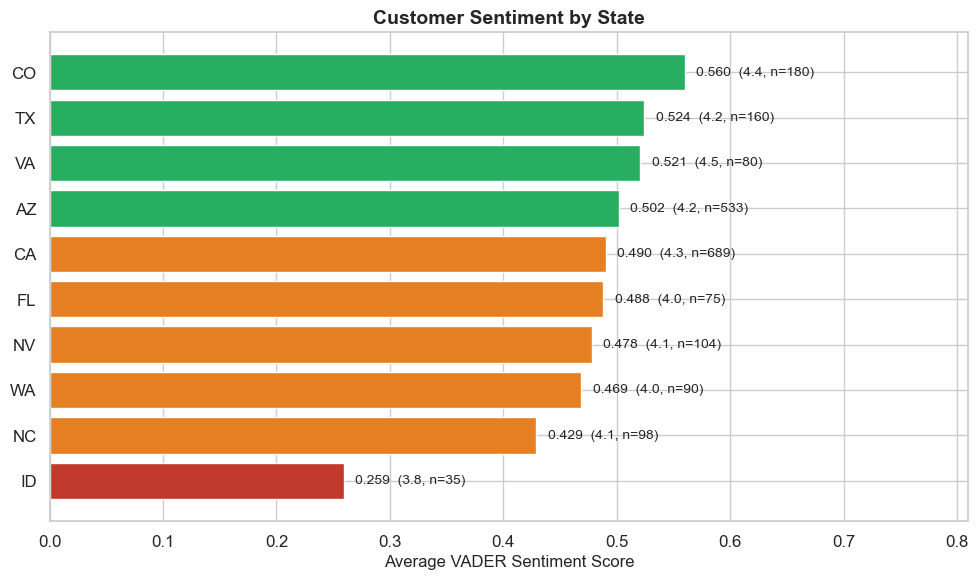

In [14]:
state_sent = df.groupby("state").agg(
    avg_vader=("vader_compound", "mean"),
    avg_stars=("total_score", "mean"),
    pct_negative=("vader_label", lambda x: (x == "Negative").mean()),
    count=("total_score", "count")
).sort_values("avg_vader", ascending=True)
state_sent = state_sent[state_sent["count"] >= 10]

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ["#27ae60" if v >= 0.5 else "#e67e22" if v >= 0.3 else "#c0392b" for v in state_sent["avg_vader"]]
bars = ax.barh(state_sent.index, state_sent["avg_vader"], color=bar_colors, edgecolor="white")

for bar, vader, stars, count in zip(bars, state_sent["avg_vader"], state_sent["avg_stars"], state_sent["count"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{vader:.3f}  ({stars:.1f}, n={count})",
            ha="left", va="center", fontsize=10)

ax.set_xlabel("Average VADER Sentiment Score", fontsize=12)
ax.set_title("Customer Sentiment by State", fontsize=14, fontweight="bold")
ax.set_xlim(0, max(state_sent["avg_vader"]) + 0.25)

plt.tight_layout()
plt.show()

Most states show consistently positive sentiment, with scores clustering between 0.45 and 0.55. Colorado and Texas rank among the highest, showing positive review language in those markets.

North Carolina and Idaho appear lower in comparison, suggesting that customer experiences in those markets may warrant closer examination. California and Arizona, the two markets with the largest number of reviews, remain positive, showing stable customer sentiment in Shea Homes’ largest operating regions.


## 3.5 What Are Unhappy Customers Talking About?
This analysis examines the most frequently used words in positive and negative reviews. The charts compare language used in 1–2 star reviews with language used in 4–5 star reviews. By analyzing which terms appear most often in each group, we can identify the themes that customers associate with positive experiences and the issues that appear most often in negative feedback.


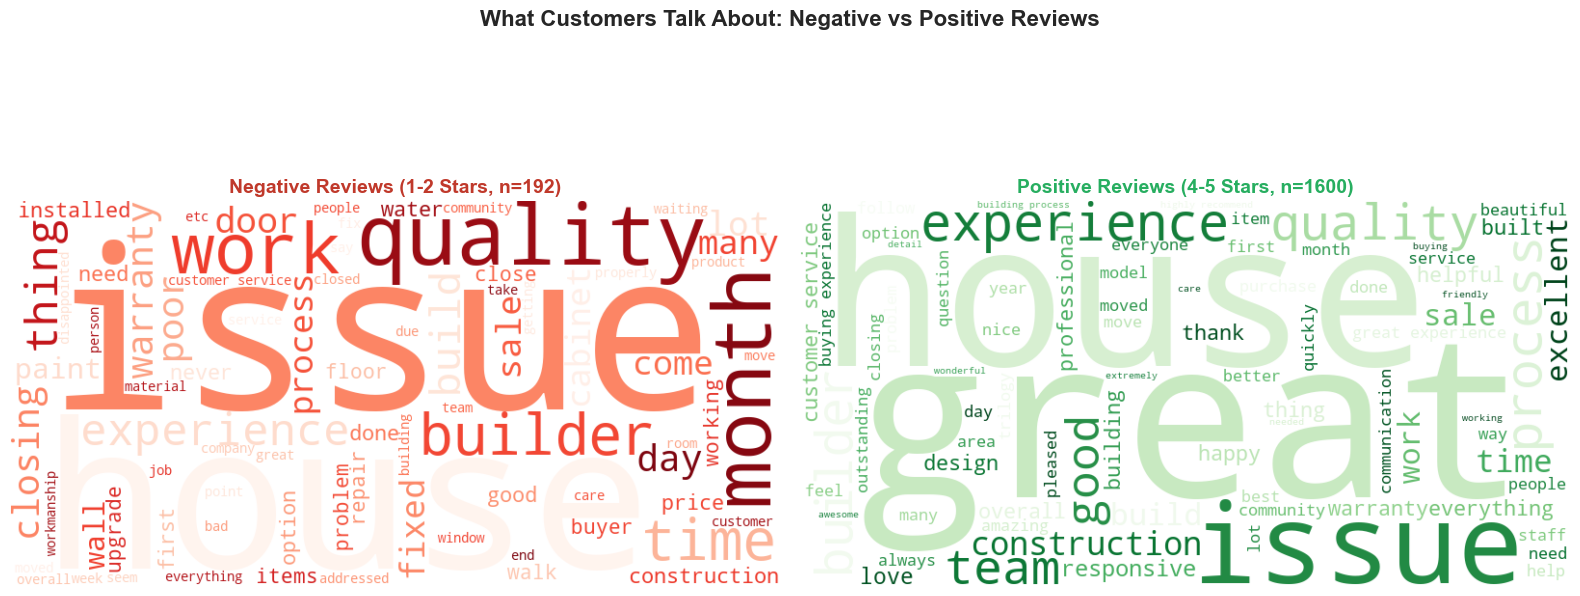

In [17]:
stop_words = set(stopwords.words("english"))
# add domain-specific stop words that aren't meaningful 
stop_words.update([
    "home", "shea", "homes", "new", "would", "one", "us",
    "also", "get", "got", "even", "like", "really", "much",
    "could", "said", "told", "went", "going", "still", "back",
    "made", "make", "well", "since", "every"
])

def get_clean_words(texts):
    """Extract meaningful words from a collection of review texts."""
    all_text = " ".join(texts.astype(str)).lower()
    words = re.findall(r"[a-z']+", all_text)
    return [w for w in words if w not in stop_words and len(w) > 2]

# split into groups based on star rating for cleaner separation
neg_reviews = df[df["total_score"] <= 2]["review_text"]
pos_reviews = df[df["total_score"] >= 4]["review_text"]

neg_words = get_clean_words(neg_reviews)
pos_words = get_clean_words(pos_reviews)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# negative word cloud
if neg_words:
    wc_neg = WordCloud(width=800, height=400, background_color="white",
                       colormap="Reds", max_words=80, min_font_size=10).generate(" ".join(neg_words))
    axes[0].imshow(wc_neg, interpolation="bilinear")
axes[0].set_title(f"Negative Reviews (1-2 Stars, n={len(neg_reviews)})", fontsize=14, fontweight="bold", color="#c0392b")
axes[0].axis("off")

# positive word cloud
if pos_words:
    wc_pos = WordCloud(width=800, height=400, background_color="white",
                       colormap="Greens", max_words=80, min_font_size=10).generate(" ".join(pos_words))
    axes[1].imshow(wc_pos, interpolation="bilinear")
axes[1].set_title(f"Positive Reviews (4-5 Stars, n={len(pos_reviews)})", fontsize=14, fontweight="bold", color="#27ae60")
axes[1].axis("off")

plt.suptitle("What Customers Talk About: Negative vs Positive Reviews", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Negative reviews frequently reference words such as issues, quality, warranty, time, and construction, indicating that dissatisfaction is often related to build quality or delays in resolving problems after purchase. In contrast, positive reviews emphasize words such as experience, team, process, and service, suggesting that customers frequently highlight interactions with staff and the overall buying process when describing a positive experience. This contrast suggests that customer-facing interactions are a key strength, while product quality and issue resolution appear more often in negative feedback.

## 3.6 Most Common Themes in Negative Reviews

This table identifies words that appear disproportionately often in negative reviews compared with positive reviews. Instead of simply counting the most common words, the analysis measures how much more frequently a word appears in complaints than in positive feedback. Words with high overrepresentation scores are strongly associated with dissatisfied customer experiences.

In [20]:
# count the most common meaningful words in negative vs positive reviews
neg_counter = Counter(neg_words)
pos_counter = Counter(pos_words)

# find words that are disproportionately common in negative reviews
# (normalized by group size to account for different sample sizes)
neg_rate = {w: c / len(neg_reviews) for w, c in neg_counter.most_common(200)}
pos_rate = {w: c / len(pos_reviews) for w, c in pos_counter.most_common(200)}

# words much more common in negative reviews
neg_distinctive = []
for word, rate in sorted(neg_rate.items(), key=lambda x: -x[1]):
    pos_r = pos_rate.get(word, 0.001)
    ratio = rate / pos_r
    if ratio > 1.5 and neg_counter[word] >= 10:
        neg_distinctive.append((word, neg_counter[word], ratio))

print("WORDS UNIQUELY COMMON IN NEGATIVE REVIEWS (1-2 stars)")
print("These words appear much more frequently in bad reviews than good ones.")
print("=" * 60)
print(f"{'Word':<20} {'Count':<10} {'Overrepresentation':<20}")
print("-" * 60)
for word, count, ratio in sorted(neg_distinctive, key=lambda x: -x[2])[:20]:
    print(f"{word:<20} {count:<10} {ratio:.1f}x more than positive")

WORDS UNIQUELY COMMON IN NEGATIVE REVIEWS (1-2 stars)
These words appear much more frequently in bad reviews than good ones.
Word                 Count      Overrepresentation  
------------------------------------------------------------
poor                 37         192.7x more than positive
installed            27         140.6x more than positive
bad                  25         130.2x more than positive
list                 24         125.0x more than positive
cabinets             21         109.4x more than positive
waiting              21         109.4x more than positive
disappointed         20         104.2x more than positive
point                19         99.0x more than positive
etc                  19         99.0x more than positive
closed               19         99.0x more than positive
properly             19         99.0x more than positive
contract             19         99.0x more than positive
wall                 18         93.8x more than positive
worst        

Words like poor (192.7x more common in negative reviews), installed (140.6x), cabinets (109.4x), and flooring (83.3x) point to specific construction pain points. The word waiting (109.4x) and months suggest delays are a major theme. These are not abstract complaints; they are about specific, fixable things: cabinets installed wrong, flooring issues, and long wait times for repairs.

## 3.7 Score vs. Sentiment Mismatch

This section identifies reviews where the star rating and the language of the review do not align. In most cases, higher star ratings are associated with positive wording, while lower ratings contain more negative language. When these signals disagree, it can show more complexity in the customer experience that star ratings alone may not capture.

One important category is high-star reviews with negative sentiment in the text. These reviews often show that a customer was generally satisfied but still experienced specific problems worth noting. Identifying these cases helps surface issues that may otherwise be overlooked when focusing only on low star ratings.


In [23]:
# find mismatches: high stars but negative text, or low stars but positive text
df["mismatch"] = False

# high stars (4-5) but negative sentiment
high_star_neg = (df["total_score"] >= 4) & (df["vader_compound"] < -0.05)
# low stars (1-2) but positive sentiment  
low_star_pos = (df["total_score"] <= 2) & (df["vader_compound"] > 0.5)

df.loc[high_star_neg | low_star_pos, "mismatch"] = True

print(f"Total mismatch reviews: {df['mismatch'].sum()} ({df['mismatch'].mean():.1%} of all reviews)")
print(f"  High stars, negative text: {high_star_neg.sum()}")
print(f"  Low stars, positive text:  {low_star_pos.sum()}")

# show some examples of high-star negative-text reviews (hidden complaints)
print("\n" + "=" * 70)
print("HIDDEN COMPLAINTS: Customers gave 4-5 stars but wrote negative text")
print("These are customers who were generally happy but had specific issues.")
print("=" * 70)

hidden_complaints = df[high_star_neg].sort_values("vader_compound").head(5)
for _, row in hidden_complaints.iterrows():
    print(f"\n{row['total_score']} Stars| VADER: {row['vader_compound']:.3f} | {row['location']}")
    print(f"  \"{row['review_text'][:250]}{'...' if len(str(row['review_text'])) > 250 else ''}\"")

Total mismatch reviews: 146 (7.1% of all reviews)
  High stars, negative text: 110
  Low stars, positive text:  36

HIDDEN COMPLAINTS: Customers gave 4-5 stars but wrote negative text
These are customers who were generally happy but had specific issues.

5 Stars| VADER: -0.991 | Conroe, TX
  "The subcontractor PSG Landscaping is ruining your reputation as a stellar builder. Between the combination of our warranty manager and PSG, our experience is: • Both our front and back lawns are completely riddled with lumps under the grass where you..."

5 Stars| VADER: -0.987 | Avondale, AZ
  "The house is beautifull from the display but once you settle in things begin to appear out of place. I give an overall 3-star experince because the sellers witheld critical information or bully me after I signed the deal and found issues that needed ..."

4 Stars| VADER: -0.973 | Littleton, CO
  "The majority of the experience has been awesome. Many of the personnel with whom we have interacted have been o

A total of 146 reviews (7.2% of the dataset) show a mismatch between the rating and the sentiment expressed in the text. The majority of these cases, 110 reviews, are high-star ratings paired with negative language, indicating customers who reported specific issues despite assigning an overall positive score. These reviews are particularly valuable from an operational perspective. Because the customer still left a favorable rating, the relationship is largely intact, yet the written feedback highlights clear opportunities for improvement, such as subcontractor performance, installation quality, or post-closing service.

## 3.8 Sample Reviews by Sentiment
To show how the sentiment models interpret review text, this section gives real examples from the dataset across different sentiment categories. These examples help translate the numerical sentiment scores into the type of language customers actually use when describing their experiences.


In [26]:
def show_reviews(label, n=3):
    """Display sample reviews for a given sentiment category."""
    if label == "Positive":
        subset = df[df["vader_label"] == label].nlargest(n, "vader_compound")
    elif label == "Negative":
        subset = df[df["vader_label"] == label].nsmallest(n, "vader_compound")
    else:
        subset = df[df["vader_label"] == label].head(n)
    
    for _, row in subset.iterrows():
        print(f"{row['total_score']} Stars | {row['location']} | {row['date'].strftime('%b %Y')} | VADER: {row['vader_compound']:.3f}")
        text = str(row["review_text"])
        print(f"  \"{text[:300]}{'...' if len(text) > 300 else ''}\"")
        print()

print("=" * 70)
print("MOST POSITIVE REVIEWS (highest sentiment scores)")
print("=" * 70)
show_reviews("Positive")

print("=" * 70)
print("MOST NEGATIVE REVIEWS (lowest sentiment scores)")
print("=" * 70)
show_reviews("Negative")

print("=" * 70)
print("NEUTRAL REVIEWS (mixed or factual tone)")
print("=" * 70)
show_reviews("Neutral")

MOST POSITIVE REVIEWS (highest sentiment scores)
5 Stars | Cave Creek, AZ | May 2025 | VADER: 0.999
  "The Sales team at The Reserves Lone Mountain was always helpful, responsive and made the process less stressful. Overall I give the sales Team 5 stars. Everyone was always helpful and sincerely cared for my concerns. The only thing that is stressful is that non of the other departments that handle e..."

5 Stars | Mission Viejo, CA | Jun 2023 | VADER: 0.998
  "I recently had the pleasure of working with Shea Homes® Neo at Mission Foothills Builder for the construction of my new home, and I couldn't be more pleased with the experience. From start to finish, they demonstrated a commitment to excellence, delivering my home on time and surpassing my expectati..."

5 Stars | Peoria, AZ | Jan 2025 | VADER: 0.998
  "Our experience with Shea Homes has been outstanding from start to finish, and we are absolutely thrilled with our new home in the Aloravita community! From the very first moment 

Positive reviews typically contain enthusiastic language and references to specific employees, teams, or smooth buying experiences. Negative reviews, in contrast, tend to focus on specific construction defects, installation problems, or delays in resolving issues. Neutral reviews generally contain short or factual statements with little emotional language, which results in sentiment scores near zero. Reviewing these examples provides context for how the sentiment algorithms classify text and what each sentiment category represents in practice.
